# Modelo 1: Regresión Logística

En este notebook se entrena un modelo de Regresión Logística para clasificar el nivel de cobertura de vacunación por departamento.

La variable objetivo será:

`nivel_cobertura`

El objetivo es predecir si una cobertura pertenece a una categoría como:

- Muy baja
- Baja
- Media
- Adecuada
- Alta

Este modelo se usará como modelo base para compararlo posteriormente con Árbol de Decisión, Random Forest y XGBoost.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importar librerías principales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Métricas de evaluación

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Para guardar resultados

import os
import joblib

In [3]:
# Cargar dataset limpio

ruta = "../Datos/datos_limpios_coberturas_vacunacion.csv"

df = pd.read_csv(ruta)

df.head()

,cod_departamento,departamento,anio,biologico,cobertura_vacunacion,estado_indicador,rango_bajo_inicio,rango_bajo_fin,rango_medio_inicio,rango_medio_fin,rango_adecuado_inicio,rango_adecuado_fin,cobertura_original,cobertura_porcentaje,nivel_cobertura
0,5,Antioquia,2019,BCG - Antituberculosa Recién Nacido,0.9389,ThreeSymbolUnCircledCheck,0,49.99,80,89.99,90,94.99,0.9389,93.89,Adecuada
1,8,Atlántico,2019,BCG - Antituberculosa Recién Nacido,1.0379,IndicatorState3,0,49.99,80,89.99,90,94.99,10379.0000,103.79,Alta
2,11,Bogotá D.C.,2019,BCG - Antituberculosa Recién Nacido,1.0105,IndicatorState3,0,49.99,80,89.99,90,94.99,10105.0000,101.05,Alta
3,13,Bolívar,2019,BCG - Antituberculosa Recién Nacido,0.7170,IndicatorState1,0,49.99,80,89.99,90,94.99,0.7170,71.70,Baja
4,15,Boyacá,2019,BCG - Antituberculosa Recién Nacido,0.9409,ThreeSymbolUnCircledCheck,0,49.99,80,89.99,90,94.99,0.9409,94.09,Adecuada


In [4]:
# Tamaño del dataset

print("Filas y columnas:", df.shape)

Filas y columnas: (660, 15)


In [5]:
# Información general

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cod_departamento       660 non-null    int64  
 1   departamento           660 non-null    str    
 2   anio                   660 non-null    int64  
 3   biologico              660 non-null    str    
 4   cobertura_vacunacion   660 non-null    float64
 5   estado_indicador       660 non-null    str    
 6   rango_bajo_inicio      660 non-null    int64  
 7   rango_bajo_fin         660 non-null    float64
 8   rango_medio_inicio     660 non-null    int64  
 9   rango_medio_fin        660 non-null    float64
 10  rango_adecuado_inicio  660 non-null    int64  
 11  rango_adecuado_fin     660 non-null    float64
 12  cobertura_original     660 non-null    float64
 13  cobertura_porcentaje   660 non-null    float64
 14  nivel_cobertura        660 non-null    str    
dtypes: float64(6), in

In [6]:
# Revisar columnas disponibles

df.columns

Index(['cod_departamento', 'departamento', 'anio', 'biologico',
       'cobertura_vacunacion', 'estado_indicador', 'rango_bajo_inicio',
       'rango_bajo_fin', 'rango_medio_inicio', 'rango_medio_fin',
       'rango_adecuado_inicio', 'rango_adecuado_fin', 'cobertura_original',
       'cobertura_porcentaje', 'nivel_cobertura'],
      dtype='str')

In [7]:
# Revisar distribución de la variable objetivo

df["nivel_cobertura"].value_counts()

nivel_cobertura
Media       189
Muy baja    140
Baja        128
Adecuada    104
Alta         99
Name: count, dtype: int64

In [8]:
# Distribución porcentual

df["nivel_cobertura"].value_counts(normalize=True).map("{:.2%}".format)

nivel_cobertura
Media       28.64%
Muy baja    21.21%
Baja        19.39%
Adecuada    15.76%
Alta        15.00%
Name: proportion, dtype: str

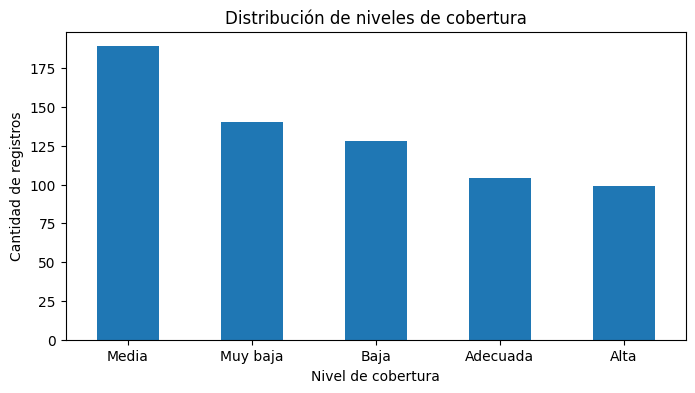

In [9]:
# Gráfico de distribución de la variable objetivo

plt.figure(figsize=(8, 4))

df["nivel_cobertura"].value_counts().plot(kind="bar")

plt.title("Distribución de niveles de cobertura")
plt.xlabel("Nivel de cobertura")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=0)

plt.show()

## Selección de variables

Para entrenar el modelo no se utilizarán las columnas relacionadas directamente con la cobertura, porque la variable objetivo `nivel_cobertura` fue creada a partir de la cobertura en porcentaje.

Por esta razón, se excluyen variables como:

- `cobertura_vacunacion`
- `cobertura_porcentaje`
- `cobertura_original`
- `estado_indicador`

Esto se hace para evitar que el modelo aprenda la respuesta directamente y genere resultados artificialmente altos.

In [10]:
# Variable objetivo

y = df["nivel_cobertura"]

# Variables predictoras

X = df[[
    "cod_departamento",
    "departamento",
    "anio",
    "biologico"
]]

X.head()

,cod_departamento,departamento,anio,biologico
0,5,Antioquia,2019,BCG - Antituberculosa Recién Nacido
1,8,Atlántico,2019,BCG - Antituberculosa Recién Nacido
2,11,Bogotá D.C.,2019,BCG - Antituberculosa Recién Nacido
3,13,Bolívar,2019,BCG - Antituberculosa Recién Nacido
4,15,Boyacá,2019,BCG - Antituberculosa Recién Nacido


In [11]:
# Identificar variables numéricas y categóricas

variables_numericas = ["cod_departamento", "anio"]
variables_categoricas = ["departamento", "biologico"]

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

Variables numéricas: ['cod_departamento', 'anio']
Variables categóricas: ['departamento', 'biologico']


In [12]:
# Dividir los datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)

Tamaño X_train: (495, 4)
Tamaño X_test: (165, 4)
Tamaño y_train: (495,)
Tamaño y_test: (165,)


In [13]:
# Preprocesamiento para variables numéricas y categóricas

preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), variables_categoricas)
    ]
)

# Crear modelo de Regresión Logística

modelo_regresion_logistica = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Crear pipeline completo

pipeline_regresion_logistica = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", modelo_regresion_logistica)
    ]
)

pipeline_regresion_logistica

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [14]:
# Entrenar el modelo

pipeline_regresion_logistica.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


In [15]:
# Realizar predicciones

y_pred = pipeline_regresion_logistica.predict(X_test)

y_pred[:10]

array(['Baja', 'Baja', 'Media', 'Media', 'Muy baja', 'Media', 'Muy baja',
       'Baja', 'Adecuada', 'Media'], dtype=object)

In [16]:
# Calcular métricas principales

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("=== MÉTRICAS REGRESIÓN LOGÍSTICA ===")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

=== MÉTRICAS REGRESIÓN LOGÍSTICA ===
Accuracy: 0.5455
Precision: 0.5447
Recall: 0.5455
F1 Score: 0.5417


In [17]:
# Reporte detallado por clase

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred, zero_division=0))

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

    Adecuada       0.30      0.23      0.26        26
        Alta       0.49      0.68      0.57        25
        Baja       0.41      0.41      0.41        32
       Media       0.47      0.45      0.46        47
    Muy baja       1.00      0.94      0.97        35

    accuracy                           0.55       165
   macro avg       0.53      0.54      0.53       165
weighted avg       0.54      0.55      0.54       165



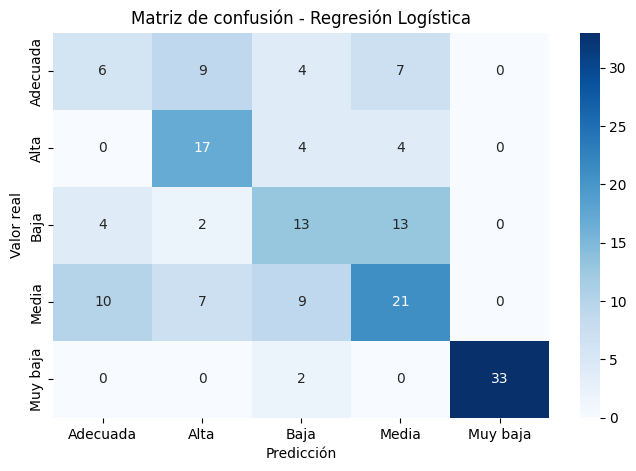

In [18]:
# Crear matriz de confusión

matriz = confusion_matrix(y_test, y_pred, labels=pipeline_regresion_logistica.classes_)

plt.figure(figsize=(8, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=pipeline_regresion_logistica.classes_,
    yticklabels=pipeline_regresion_logistica.classes_
)

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [19]:
# Crear carpeta de resultados si no existe

os.makedirs("../Resultados", exist_ok=True)

# Guardar métricas en un dataframe

resultados_regresion = pd.DataFrame({
    "modelo": ["Regresión Logística"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1_score": [f1]
})

resultados_regresion

,modelo,accuracy,precision,recall,f1_score
0,Regresión Logística,0.545455,0.544704,0.545455,0.541675


In [20]:
# Guardar resultados en CSV

resultados_regresion.to_csv(
    "../Resultados/metricas_regresion_logistica.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Métricas guardadas correctamente.")

Métricas guardadas correctamente.


In [21]:
# Crear carpeta para guardar modelos entrenados

os.makedirs("../Modelos_entrenados", exist_ok=True)

# Guardar modelo

joblib.dump(
    pipeline_regresion_logistica,
    "../Modelos_entrenados/modelo_regresion_logistica.pkl"
)

print("Modelo de Regresión Logística guardado correctamente.")

Modelo de Regresión Logística guardado correctamente.


## Interpretación del modelo

La Regresión Logística se utilizó como modelo base para clasificar los niveles de cobertura de vacunación.

Este modelo permite tener una primera referencia del desempeño antes de compararlo con modelos más complejos como Árbol de Decisión, Random Forest y XGBoost.

Las métricas utilizadas fueron:

- Accuracy
- Precision
- Recall
- F1 Score

El F1 Score es especialmente importante porque permite evaluar el equilibrio entre la precisión y la capacidad del modelo para identificar correctamente las clases.